In [ ]:
from google.colab import auth
auth.authenticate_user()
import gspread
from oauth2client.client import GoogleCredentials
gc = gspread.authorize(GoogleCredentials.get_application_default())

In [ ]:
import pandas as pd
wb = gc.open_by_url('https://docs.google.com/spreadsheets/d/1IjmKRQIugL5MVFASD6H_su9C_ZVj6odtkF3Guh12OZ4/edit?usp=sharing')
sheet = wb.worksheet('Sheet1')

# Now that we have the tab specified it’s time to get the data. To do this we will just call the get_all_values() function off of the sheet object we created above:
data = sheet.get_all_values()

df = pd.DataFrame(data[1:])
df.columns = data[0]

In [ ]:
import numpy as np
df[df==''] = np.nan

df = df.dropna(axis=0)
df.to_csv('PurpleColorConstituentsSurveyData_dualClass.csv', index=None)

In [ ]:
df['R'] = df['R'].astype('int8')
df['G'] = df['G'].astype('int8')
df['B'] = df['B'].astype('int8')
df['Class'] = df['Class'].astype('category')
df = df.drop(['Who Thinks So'], axis=1)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [ ]:
df['Class'].value_counts()

Purple        24
Not Purple    18
Name: Class, dtype: int64

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 42 entries, 0 to 42
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   R       42 non-null     int8    
 1   G       42 non-null     int8    
 2   B       42 non-null     int8    
 3   Class   42 non-null     category
dtypes: category(1), int8(3)
memory usage: 628.0 bytes


In [ ]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = df.drop(['Class'], axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)

classifier = LogisticRegression(penalty='l2', solver='sag', C=1)
start_time = time.time()
fit2 = classifier.fit(X_train, y_train)
end_time = time.time()
time3 = end_time-start_time
print(time3)

y_pred = fit2.predict(X_test)

from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(cm)
print(cr)


0.004928112030029297
[[2 6]
 [0 5]]
              precision    recall  f1-score   support

  Not Purple       1.00      0.25      0.40         8
      Purple       0.45      1.00      0.62         5

    accuracy                           0.54        13
   macro avg       0.73      0.62      0.51        13
weighted avg       0.79      0.54      0.49        13



/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:783: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  FutureWarning,
/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_t_sne.py:793: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  FutureWarning,


Text(0.5, 1.0, 'TSNE')

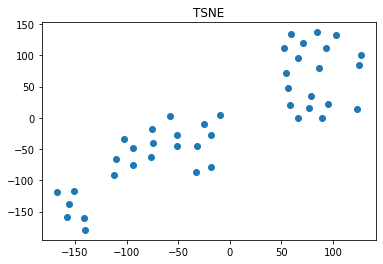

In [ ]:
#T-SNE
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

X = df.drop(['Class'], axis=1)
digit_tsne = TSNE(n_components=2,perplexity=10,method='exact') #, random_state=4) 

tsne_projections = digit_tsne.fit_transform(X)
plt.scatter(tsne_projections[:,0],tsne_projections[:,1]) #,c=Names,edgecolor="none",cmap=plt.cm.get_cmap('nipy_spectral'));plt.colorbar()
plt.title('TSNE')



In [ ]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(tsne_projections, y, test_size = 0.3, random_state = 0)

classifier = LogisticRegression(penalty='l2', solver='sag', C=1)
start_time = time.time()
fit2 = classifier.fit(X_train, y_train)
end_time = time.time()
time3 = end_time-start_time
print(time3)

y_pred = fit2.predict(X_test)

from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)

print(cm)
print(cr)


0.0019936561584472656
[[5 3]
 [1 4]]
              precision    recall  f1-score   support

  Not Purple       0.83      0.62      0.71         8
      Purple       0.57      0.80      0.67         5

    accuracy                           0.69        13
   macro avg       0.70      0.71      0.69        13
weighted avg       0.73      0.69      0.70        13



In [ ]:
from sklearn import metrics
def Find_Optimal_Cutoff(target, predicted):
    """ Find the optimal probability cutoff point for a classification model related to event rate
    Parameters
    ----------
    target : Matrix with dependent or target data, where rows are observations
    predicted : Matrix with predicted data, where rows are observations
    Returns
    -------    
    list type, with optimal cutoff value
    """
    fpr, tpr, threshold = metrics.roc_curve(target, predicted)
    i = np.arange(len(tpr))
    roc = pd.DataFrame({'tf' : pd.Series(tpr-(1-fpr), index=i), 'threshold' : pd.Series(threshold, index=i)})
    roc_t = roc.iloc[(roc.tf-0).abs().argsort()[:1]]
    return roc_t['threshold']

y_pred_train_proba = fit2.predict_proba(X_train)

threshold = Find_Optimal_Cutoff(y_train=="Purple", y_pred_train_proba[:,1])

y_pred_test_proba = fit2.predict_proba(X_test)

# threshold = Find_Optimal_Cutoff(y_test=="Purple", y_pred_test_proba[:,1])

from sklearn.metrics import confusion_matrix,classification_report
print("Training Set:")
cm = confusion_matrix(y_train=="Purple", y_pred_train_proba[:,1]>float(threshold))
cr = classification_report(y_train=="Purple", y_pred_train_proba[:,1]>float(threshold))

print(cm)
print(cr)

print("Test Set:")
cm = confusion_matrix(y_test=="Purple", y_pred_test_proba[:,1]>float(threshold))
cr = classification_report(y_test=="Purple", y_pred_test_proba[:,1]>float(threshold))

print(cm)
print(cr)


Training Set:
[[ 8  2]
 [ 5 14]]
              precision    recall  f1-score   support

       False       0.62      0.80      0.70        10
        True       0.88      0.74      0.80        19

    accuracy                           0.76        29
   macro avg       0.75      0.77      0.75        29
weighted avg       0.79      0.76      0.76        29

Test Set:
[[6 2]
 [2 3]]
              precision    recall  f1-score   support

       False       0.75      0.75      0.75         8
        True       0.60      0.60      0.60         5

    accuracy                           0.69        13
   macro avg       0.68      0.68      0.68        13
weighted avg       0.69      0.69      0.69        13



Sen=1.0 & Spec=0.0
Sen=0.9473684210526315 & Spec=0.0
Sen=0.9473684210526315 & Spec=0.1
Sen=0.8421052631578947 & Spec=0.4
Sen=0.8421052631578947 & Spec=0.6
Sen=0.7894736842105263 & Spec=0.7
Sen=0.5263157894736842 & Spec=1.0
Sen=0.21052631578947367 & Spec=1.0
Sen=0.0 & Spec=1.0
Sen=0.0 & Spec=1.0


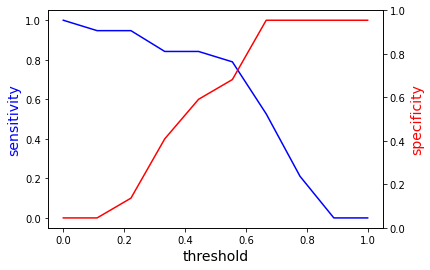

In [ ]:
import pandas as pd
# df = pd.DataFrame({'actual': y_test=="Purple", 'probability':y_pred_test_proba[:,1]})
df = pd.DataFrame({'actual': y_train=="Purple", 'probability':y_pred_train_proba[:,1]})

# optimizer
matrix=[]
for i in np.linspace(0,1,10):
    df1=df.copy()
    df1['y_pred']=df1['probability']>i
    df1['y_pred']=df1['y_pred'] #.astype('int')
    df1['y_pred']=df1['y_pred'].astype(str)
    df1['actual']=df1['actual'].astype(str)
    cm=confusion_matrix(df1.actual,df1.y_pred)        
    TN=cm[0][0]
    TP=cm[1][1]
    FP=cm[0][1]
    FN=cm[1][0]
    Sen=TP/(TP+FN)
    Spec=TN/(TN+FP)
    print('Sen={Sen} & Spec={Spec}'.format(Sen=Sen,Spec=Spec))
    m=[i,Sen,Spec]
    matrix.append(m)
        
matrix1=pd.DataFrame(matrix,columns=['threshold','sensitivity','specificity'])

def graphs(x1):
    fig,ax = plt.subplots()
    ax.plot(x1.threshold,x1.sensitivity,color="blue")
    ax.set_xlabel("threshold",fontsize=14)
    ax.set_ylabel("sensitivity",color="blue",fontsize=14)
    ax2=ax.twinx()
    ax.plot(x1.threshold,x1.specificity,color="red")
    ax2.set_ylabel("specificity",color="red",fontsize=14)
    
graphs(matrix1)

Sen=1.0 & Spec=0.0
Sen=1.0 & Spec=0.0
Sen=1.0 & Spec=0.375
Sen=1.0 & Spec=0.5
Sen=1.0 & Spec=0.625
Sen=0.8 & Spec=0.75
Sen=0.4 & Spec=0.875
Sen=0.0 & Spec=0.875
Sen=0.0 & Spec=1.0
Sen=0.0 & Spec=1.0


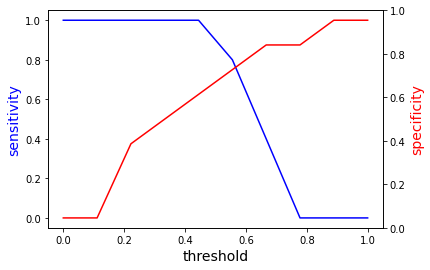

In [ ]:
import pandas as pd
df = pd.DataFrame({'actual': y_test=="Purple", 'probability':y_pred_test_proba[:,1]})

# optimizer
matrix=[]
for i in np.linspace(0,1,10):
    df1=df.copy()
    df1['y_pred']=df1['probability']>i
    df1['y_pred']=df1['y_pred'] #.astype('int')
    df1['y_pred']=df1['y_pred'].astype(str)
    df1['actual']=df1['actual'].astype(str)
    cm=confusion_matrix(df1.actual,df1.y_pred)        
    TN=cm[0][0]
    TP=cm[1][1]
    FP=cm[0][1]
    FN=cm[1][0]
    Sen=TP/(TP+FN)
    Spec=TN/(TN+FP)
    print('Sen={Sen} & Spec={Spec}'.format(Sen=Sen,Spec=Spec))
    m=[i,Sen,Spec]
    matrix.append(m)
        
matrix1=pd.DataFrame(matrix,columns=['threshold','sensitivity','specificity'])

def graphs(x1):
    fig,ax = plt.subplots()
    ax.plot(x1.threshold,x1.sensitivity,color="blue")
    ax.set_xlabel("threshold",fontsize=14)
    ax.set_ylabel("sensitivity",color="blue",fontsize=14)
    ax2=ax.twinx()
    ax.plot(x1.threshold,x1.specificity,color="red")
    ax2.set_ylabel("specificity",color="red",fontsize=14)
    
graphs(matrix1)

# One class SVM

In [ ]:
import pandas as pd
wb = gc.open_by_url('https://docs.google.com/spreadsheets/d/1IjmKRQIugL5MVFASD6H_su9C_ZVj6odtkF3Guh12OZ4/edit?usp=sharing')
sheet = wb.worksheet('Sheet1')

# Now that we have the tab specified it’s time to get the data. To do this we will just call the get_all_values() function off of the sheet object we created above:
data = sheet.get_all_values()

df = pd.DataFrame(data[1:])
df.columns = data[0]

import numpy as np
df[df==''] = np.nan

df = df.dropna(axis=0)
df.to_csv('PurpleColorConstituentsSurveyData_dualClass.csv', index=None)

df['R'] = df['R'].astype('int8')
df['G'] = df['G'].astype('int8')
df['B'] = df['B'].astype('int8')
df['Class'] = df['Class'].astype('category')
df = df.drop(['Who Thinks So'], axis=1)


print(df.Class.value_counts())

df.head()


Purple        24
Not Purple    18
Name: Class, dtype: int64


,R,G,B,Class
0,-35,62,-51,Purple
1,-99,47,-75,Purple
2,-128,0,-1,Purple
3,-108,0,-45,Purple
4,-111,55,-43,Purple


In [ ]:
from sklearn.svm import OneClassSVM

def do_svm(train_data, test_data):
    svm = OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)
    svm.fit(train_data)
    svm_predictions = svm.predict(test_data)
    svm_predMargins = svm.score_samples(test_data)
    pct_outliers = np.sum(svm_predictions == -1) / len(svm_predictions)

    return svm_predictions, svm_predMargins, pct_outliers

# Lets select only the purple class:
dfTRAIN = df[df.Class=="Purple"].drop(['Class'], axis=1)
dfTRAIN.head()

,R,G,B
0,-35,62,-51
1,-99,47,-75
2,-128,0,-1
3,-108,0,-45
4,-111,55,-43


In [ ]:
Purple_OutlierStatus = do_svm(dfTRAIN, df.drop(['Class'], axis=1))
Purple_OutlierStatus

(array([ 1,  1,  1, -1,  1,  1, -1,  1,  1, -1,  1,  1,  1,  1, -1,  1, -1,
         1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
        -1, -1, -1, -1, -1, -1, -1, -1]),
 array([1.04496168e-01, 1.04496168e-01, 1.04687500e-01, 1.04106777e-01,
        1.04496168e-01, 1.04496168e-01, 1.04106425e-01, 1.04687500e-01,
        1.04497936e-01, 1.04106646e-01, 1.04496168e-01, 1.04496168e-01,
        1.04496608e-01, 1.04497936e-01, 1.04106425e-01, 1.04687500e-01,
        1.04106423e-01, 1.04496608e-01, 1.04106686e-01, 1.04106425e-01,
        1.04106777e-01, 9.45524411e-02, 1.04106777e-01, 1.04106646e-01,
        0.00000000e+00, 1.04106425e-01, 0.00000000e+00, 0.00000000e+00,
        8.57108757e-02, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.76143562e-03,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 4.72642431e-06,
        0.00000000e+00, 0.00000000e+00]),
 0.6904761904761905)

In [ ]:
df['SVM_outlier_status'] = Purple_OutlierStatus[0]
df['SVM_outlier_margin'] = Purple_OutlierStatus[1]
df.head()

,R,G,B,Class,SVM_outlier_status,SVM_outlier_margin
0,-35,62,-51,Purple,1,0.104496
1,-99,47,-75,Purple,1,0.104496
2,-128,0,-1,Purple,1,0.104688
3,-108,0,-45,Purple,-1,0.104107
4,-111,55,-43,Purple,1,0.104496


In [ ]:
pd.crosstab(df['Class'], df['SVM_outlier_status'])

SVM_outlier_status,-1,1
Class,,
Not Purple,18,0
Purple,11,13


In [ ]:
pd.crosstab(df['Class'], df['SVM_outlier_margin']>0.104)

SVM_outlier_margin,False,True
Class,,
Not Purple,18,0
Purple,0,24


In [ ]:
from sklearn import metrics
def Find_Optimal_Cutoff(target, predicted):
    """ Find the optimal probability cutoff point for a classification model related to event rate
    Parameters
    ----------
    target : Matrix with dependent or target data, where rows are observations
    predicted : Matrix with predicted data, where rows are observations
    Returns
    -------    
    list type, with optimal cutoff value
    """
    fpr, tpr, threshold = metrics.roc_curve(target, predicted)
    i = np.arange(len(tpr))
    roc = pd.DataFrame({'tf' : pd.Series(tpr-(1-fpr), index=i), 'threshold' : pd.Series(threshold, index=i)})
    roc_t = roc.iloc[(roc.tf-0).abs().argsort()[:1]]
    return roc_t['threshold']

threshold = Find_Optimal_Cutoff(df['Class']=="Purple", df['SVM_outlier_margin'])


from sklearn.metrics import confusion_matrix,classification_report

cm = confusion_matrix(df['Class']=="Purple", df['SVM_outlier_margin']>float(threshold))
cr = classification_report(df['Class']=="Purple", df['SVM_outlier_margin']>float(threshold))

print(cm)
print(cr)

print(threshold)

[[18  0]
 [ 1 23]]
              precision    recall  f1-score   support

       False       0.95      1.00      0.97        18
        True       1.00      0.96      0.98        24

    accuracy                           0.98        42
   macro avg       0.97      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42

9    0.104106
Name: threshold, dtype: float64


# 2 Class SVM

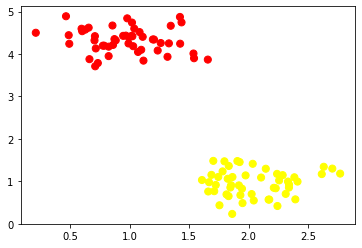

In [ ]:
import numpy as np 

# from sklearn.datasets.samples_generator import make_blobs
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.30)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

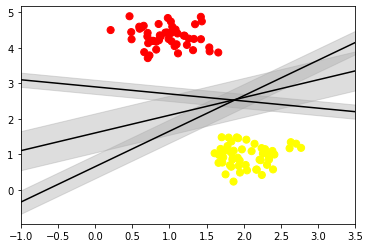

In [ ]:
xfit = np.linspace(-1, 3.5)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')

for m, b, d in [(1, 0.65, 0.33), (0.5, 1.6, 0.55), (-0.2, 2.9, 0.2)]:
    yfit = m * xfit + b
    plt.plot(xfit, yfit, '-k')
    plt.fill_between(xfit, yfit - d, yfit + d, edgecolor='none',
                     color='#AAAAAA', alpha=0.4)

plt.xlim(-1, 3.5);

In [ ]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1E10)
model.fit(X, y)

SVC(C=10000000000.0, kernel='linear')

In [ ]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

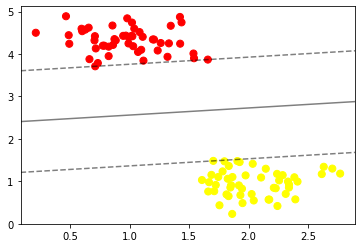

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(model);

In [ ]:
# # from sklearn.datasets.samples_generator import make_blobs
# from sklearn.datasets import make_blobs
# X, y = make_blobs(n_samples=100, centers=3,
#                   random_state=0, cluster_std=0.30)
# import matplotlib.pyplot as plt
# plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

# plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
# plot_svc_decision_function(model);

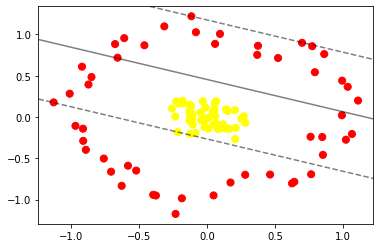

In [ ]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

clf = SVC(kernel='linear').fit(X, y)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf, plot_support=False);

In [ ]:
from mpl_toolkits import mplot3d
r = np.exp(-(X ** 2).sum(1))

from ipywidgets import interact, fixed

def plot_3D(elev=30, azim=30, X=X, y=y):
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=50, cmap='autumn')
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('r')

interact(plot_3D, elev=[-90, 90], azip=(-180, 180),
         X=fixed(X), y=fixed(y));

interactive(children=(Dropdown(description='elev', options=(-90, 90), value=-90), IntSlider(value=30, descript…

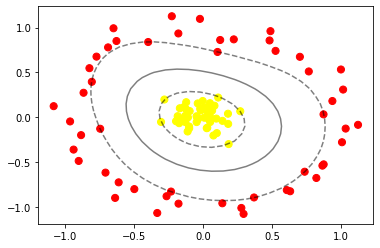

In [ ]:
clf = SVC(kernel='rbf', C=1E6)
clf.fit(X, y)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1],
            s=300, lw=1, facecolors='none');

# Apply 2 class SVM to our Purple color classification dataset

In [ ]:
import pandas as pd
wb = gc.open_by_url('https://docs.google.com/spreadsheets/d/1IjmKRQIugL5MVFASD6H_su9C_ZVj6odtkF3Guh12OZ4/edit?usp=sharing')
sheet = wb.worksheet('Sheet1')

# Now that we have the tab specified it’s time to get the data. To do this we will just call the get_all_values() function off of the sheet object we created above:
data = sheet.get_all_values()

df = pd.DataFrame(data[1:])
df.columns = data[0]

import numpy as np
df[df==''] = np.nan

df = df.dropna(axis=0)
df.to_csv('PurpleColorConstituentsSurveyData_dualClass.csv', index=None)

df['R'] = df['R'].astype('int8')
df['G'] = df['G'].astype('int8')
df['B'] = df['B'].astype('int8')
df['Class'] = df['Class'].astype('category')
df = df.drop(['Who Thinks So'], axis=1)

X1 = df.drop(['Class', 'B'], axis=1).to_numpy().astype(float)
y1 = 1*((df['Class']=='Purple').values)


In [ ]:
X1

array([[ -35.,   62.],
       [ -99.,   47.],
       [-128.,    0.],
       [-108.,    0.],
       [-111.,   55.],
       [ -67.,   77.],
       [ -87.,   26.],
       [-115.,   28.],
       [-103.,   51.],
       [  55.,   11.],
       [  70.,   58.],
       [-103.,   50.],
       [-128.,    0.],
       [ 127.,    0.],
       [ -78.,  102.],
       [  75.,    0.],
       [-128., -128.],
       [ -18., -126.],
       [ 109.,   57.],
       [ -73., -123.],
       [-108.,    0.],
       [-128.,   -1.],
       [ 101.,   60.],
       [  93.,   16.],
       [  14.,   30.],
       [ -88.,   86.],
       [  -1.,    0.],
       [   0.,   22.],
       [-128.,   -1.],
       [ 102.,   -1.],
       [   0.,    0.],
       [  -1.,   -1.],
       [  60.,   30.],
       [  54., -112.],
       [  44.,  -36.],
       [ 124.,   -4.],
       [  -1.,    0.],
       [   0.,   -1.],
       [   0.,    0.],
       [-128., -128.],
       [ -75.,  -26.],
       [  -1., -128.]])

In [ ]:
y1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

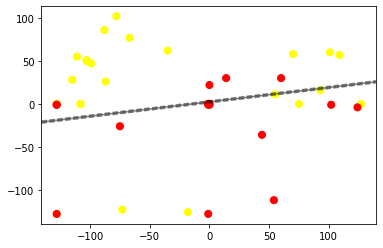

In [ ]:
from sklearn.svm import SVC # "Support vector classifier"
model1 = SVC(kernel='rbf', C=1E5)
model1.fit(X1, y1)
plt.scatter(X1[:, 0], X1[:, 1], c=y1, s=50, cmap='autumn')
plot_svc_decision_function(model);

In [ ]:
model1.predict(X1)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Naive Bayes Model for linearly separable structure delineation

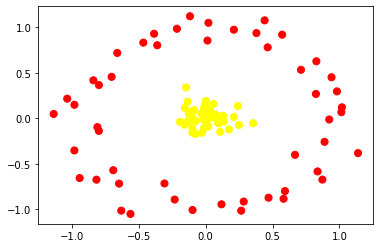

In [ ]:
import numpy as np 

# from sklearn.datasets.samples_generator import make_blobs
# from sklearn.datasets import make_blobs
# X, y = make_blobs(n_samples=100, centers=3,
#                   random_state=0, cluster_std=0.90)
# plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');


In [ ]:
from sklearn.naive_bayes import GaussianNB
model = GaussianNB()
model.fit(X, y);

yprob = model.predict_proba(X)
yprob[-10:].round(2)

array([[1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [1.  , 0.  ],
       [0.1 , 0.9 ],
       [0.05, 0.95],
       [0.69, 0.31],
       [1.  , 0.  ],
       [0.09, 0.91],
       [1.  , 0.  ]])

In [ ]:
model.predict(X)

array([0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0])

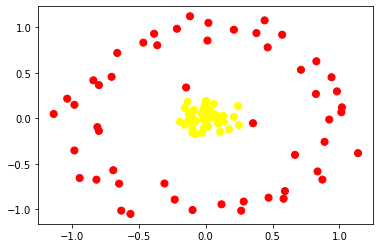

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=model.predict(X), s=50, cmap='autumn');

# Neural network :  My first fully-connected neural network for classifying scattered 2D data

#Linear classification example


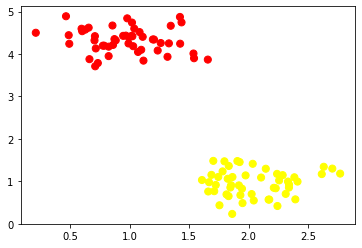

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.30)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');

In [ ]:
import pandas as pd
myDf = pd.DataFrame(X)
myDf['y'] = y
myDf['y'] = myDf['y'].astype('category')
myDf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   0       100 non-null    float64 
 1   1       100 non-null    float64 
 2   y       100 non-null    category
dtypes: category(1), float64(2)
memory usage: 1.9 KB


In [ ]:
from sklearn.model_selection import train_test_split #to split data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

# Convert y into an integer 
from sklearn.preprocessing import LabelEncoder

X=X  # Features
y=y  # Labels

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(myDf.to_numpy(), y, test_size=0.1)
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [46]:
model1 = Sequential() #Sequential Object
model1.add( Dense( 4, activation = 'relu', input_shape= X_train[0].shape))
model1.add( Dense (8, activation = 'relu'))
model1.add( Dense (2, activation = 'softmax'))

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history1 = model1.fit(X_train, y_train, epochs=10, validation_split=0.1, batch_size=10)

print(model1.summary())

Epoch 1/10
9/9 [==============================] - 1s 42ms/step - loss: 0.6432 - acc: 0.6543 - val_loss: 0.6723 - val_acc: 0.4444
Epoch 2/10
9/9 [==============================] - 0s 7ms/step - loss: 0.6305 - acc: 0.7037 - val_loss: 0.6659 - val_acc: 0.4444
Epoch 3/10
9/9 [==============================] - 0s 7ms/step - loss: 0.6178 - acc: 0.5556 - val_loss: 0.6593 - val_acc: 0.3333
Epoch 4/10
9/9 [==============================] - 0s 9ms/step - loss: 0.6059 - acc: 0.5432 - val_loss: 0.6512 - val_acc: 0.4444
Epoch 5/10
9/9 [==============================] - 0s 9ms/step - loss: 0.5948 - acc: 0.7407 - val_loss: 0.6408 - val_acc: 0.6667
Epoch 6/10
9/9 [==============================] - 0s 7ms/step - loss: 0.5833 - acc: 0.7654 - val_loss: 0.6323 - val_acc: 0.6667
Epoch 7/10
9/9 [==============================] - 0s 8ms/step - loss: 0.5728 - acc: 0.7901 - val_loss: 0.6244 - val_acc: 0.6667
Epoch 8/10
9/9 [==============================] - 0s 7ms/step - loss: 0.5605 - acc: 0.7901 - val_loss: 

In [47]:
y_predictions = model1.predict(X_test)
y_predictions

array([[0.7236522 , 0.2763478 ],
       [0.4826608 , 0.51733917],
       [0.75865114, 0.24134888],
       [0.48492378, 0.5150762 ],
       [0.550586  , 0.449414  ],
       [0.4826608 , 0.51733917],
       [0.48345906, 0.516541  ],
       [0.50454074, 0.49545926],
       [0.48266077, 0.51733917],
       [0.6634852 , 0.33651474]], dtype=float32)

In [48]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test[:,1], y_predictions[:,1]>0.5)
cr = classification_report(y_test[:,1], y_predictions[:,1]>0.5)

print(cm)
print(cr)


[[3 0]
 [2 5]]
              precision    recall  f1-score   support

         0.0       0.60      1.00      0.75         3
         1.0       1.00      0.71      0.83         7

    accuracy                           0.80        10
   macro avg       0.80      0.86      0.79        10
weighted avg       0.88      0.80      0.81        10



In [49]:
model1.evaluate(X_test, y_test)

1/1 [==============================] - 0s 21ms/step - loss: 0.5813 - acc: 0.8000


[0.5813198089599609, 0.800000011920929]

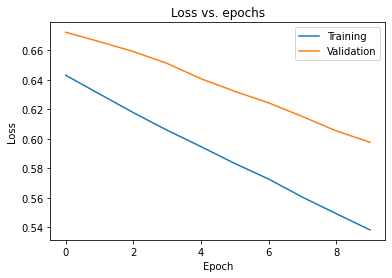

In [50]:
plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

plt.show()

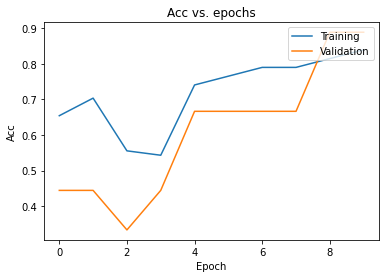

In [51]:
plt.plot(history1.history['acc'])
plt.plot(history1.history['val_acc'])
plt.title('Acc vs. epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

plt.show()

# Non linear classification example

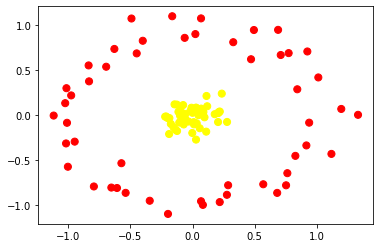

In [52]:
import numpy as np 
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn');


In [53]:
import pandas as pd
myDf = pd.DataFrame(X)
myDf['y'] = y
myDf['y'] = myDf['y'].astype('category')
myDf.info()

from sklearn.model_selection import train_test_split #to split data

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

# Convert y into an integer 
from sklearn.preprocessing import LabelEncoder

X=X  # Features
y=y  # Labels

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(myDf.to_numpy(), y, test_size=0.1)
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype   
---  ------  --------------  -----   
 0   0       100 non-null    float64 
 1   1       100 non-null    float64 
 2   y       100 non-null    category
dtypes: category(1), float64(2)
memory usage: 1.9 KB


Epoch 1/100
9/9 [==============================] - 1s 45ms/step - loss: 0.7243 - acc: 0.2840 - val_loss: 0.7039 - val_acc: 0.6667
Epoch 2/100
9/9 [==============================] - 0s 9ms/step - loss: 0.7026 - acc: 0.6420 - val_loss: 0.6901 - val_acc: 0.6667
Epoch 3/100
9/9 [==============================] - 0s 13ms/step - loss: 0.6850 - acc: 0.7160 - val_loss: 0.6762 - val_acc: 0.7778
Epoch 4/100
9/9 [==============================] - 0s 8ms/step - loss: 0.6689 - acc: 0.8272 - val_loss: 0.6643 - val_acc: 0.8889
Epoch 5/100
9/9 [==============================] - 0s 9ms/step - loss: 0.6530 - acc: 0.8889 - val_loss: 0.6507 - val_acc: 0.8889
Epoch 6/100
9/9 [==============================] - 0s 10ms/step - loss: 0.6367 - acc: 0.8889 - val_loss: 0.6374 - val_acc: 0.8889
Epoch 7/100
9/9 [==============================] - 0s 9ms/step - loss: 0.6208 - acc: 0.9136 - val_loss: 0.6217 - val_acc: 0.8889
Epoch 8/100
9/9 [==============================] - 0s 11ms/step - loss: 0.6034 - acc: 0.9136 -

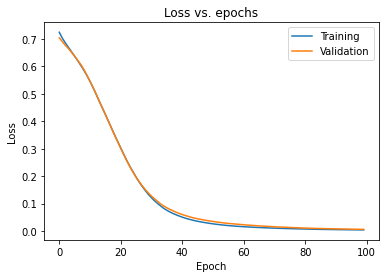

In [57]:
model1 = Sequential() #Sequential Object
model1.add( Dense( 4, activation = 'relu', input_shape= X_train[0].shape))
model1.add( Dense (8, activation = 'relu'))
model1.add( Dense (8, activation = 'relu'))
model1.add( Dense (2, activation = 'softmax'))

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['acc'])
history1 = model1.fit(X_train, y_train, epochs=100, validation_split=0.1, batch_size=10)

print(model1.summary())

y_predictions = model1.predict(X_test)
print(y_predictions)

from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(y_test[:,1], y_predictions[:,1]>0.5)
cr = classification_report(y_test[:,1], y_predictions[:,1]>0.5)

print(cm)
print(cr)

plt.plot(history1.history['loss'])
plt.plot(history1.history['val_loss'])
plt.title('Loss vs. epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

plt.show()

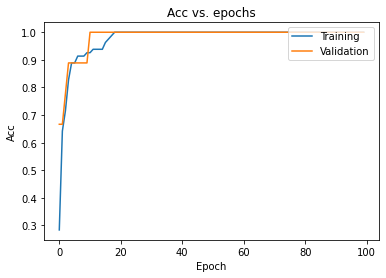

In [58]:
plt.plot(history1.history['acc'])
plt.plot(history1.history['val_acc'])
plt.title('Acc vs. epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

plt.show()